# Default Data Pipeline

In [1]:
%matplotlib inline
# Pandas is a nice utilitiy that enables some easy data manipulation, especially from a csv
import pandas as pd
# Numpy lets us work with arrays
import numpy as np
import random
# Sklearn provides various modules with a common API
from sklearn import svm, tree, neighbors, neural_network, ensemble
from sklearn.model_selection import train_test_split
# For optimizing our models' hyperparameters
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from matplotlib import pyplot as plt

# Set random seed
random.seed(100)
np.random.seed(100)

In [2]:
# Read in our csv files downloaded from Kaggle
train_data = pd.read_csv('train.csv')
test_data = pd.read_csv('test.csv')

In [3]:
random.seed(100)
np.random.seed(100)

train_data.drop(columns=['Name', 'Ticket', 'Cabin'], inplace=True)
train_data.set_index(keys=['PassengerId'], drop=True, inplace=True)

test_data.drop(columns=['Name', 'Ticket', 'Cabin'], inplace=True)
test_data.set_index(keys=['PassengerId'], drop=True, inplace=True)

train_nan_map = {'Age': train_data['Age'].mean(), 'Fare': train_data['Fare'].mean(), 'Embarked': train_data['Embarked'].mode()[0]}
test_nan_map = {'Age': test_data['Age'].mean(), 'Fare': test_data['Fare'].mean(), 'Embarked': test_data['Embarked'].mode()[0]}

train_data.fillna(value=train_nan_map, inplace=True)
test_data.fillna(value=test_nan_map, inplace=True)

columns_map = {'Embarked': {'C': 0, 'Q': 1, 'S': 2}, 'Sex': {'male': 0, 'female': 1}}
# Adding below line to surpress deprication warnings
pd.set_option('future.no_silent_downcasting', True)
train_data.replace(columns_map, inplace=True)
test_data.replace(columns_map, inplace=True)

X_train = train_data.loc[:, train_data.columns != 'Survived']
y_train = train_data.loc[:, 'Survived']

X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.33, random_state=10)

In [4]:
y_truth = y_test.values

In [5]:
# Instantiate Containers and Update Function 
x_axis1 = [] # list of lists
y_axis1 = [] # list of lists
FPR_axis = []
FNR_axis = []
name_labels = ['Boost', 'SVC','LR','KNN','RF']

def ordered_pair(tn, fp, fn, tp):
    # x-axis is the False Positive Rate, y-axis is the False Negative Rate
    fpr = fp / (fp + tn)
    fnr = fn / (fn + tp)
    return (fpr, fnr)

# Milestone 1: default hyperparameters, default data pipeline

In [6]:
# Andy - Boosted Tree
boost_clf = ensemble.GradientBoostingClassifier(random_state=100)
# Train the model
boost_clf.fit(X_train, y_train)

# Make predictions
y_pred = boost_clf.predict(X_test)

tn, fp, fn, tp = confusion_matrix(y_truth, y_pred).ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

output = ordered_pair(tn, fp, fn, tp)
FPR_axis.append(output[0])
FNR_axis.append(output[1])
print(f'FPR = {output[0]:.04f} FNR = {output[1]:.04f}')

True Negatives: 166
False Positives: 25
False Negatives: 29
True Positives: 75
FPR = 0.1309 FNR = 0.2788


In [7]:
# Stevie - SVC
svc_clf = svm.SVC()

# Train the model
svc_clf.fit(X_train.values, y_train.values)

# Make predictions
y_pred = svc_clf.predict(X_test.values)

tn, fp, fn, tp = confusion_matrix(y_test.values, y_pred).ravel()
print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

output = ordered_pair(tn, fp, fn, tp)
FPR_axis.append(output[0])
FNR_axis.append(output[1])
print(f'FPR = {output[0]:.04f} FNR = {output[1]:.04f}')

True Negatives: 182
False Positives: 9
False Negatives: 75
True Positives: 29
FPR = 0.0471 FNR = 0.7212


In [8]:
# Asher - Logistic Classification
LC = LogisticRegression()

# Train the model
LC.fit(X_train, y_train)

# Make predictions
y_pred = LC.predict(X_test)

tn, fp, fn, tp = confusion_matrix(y_test.values, y_pred).ravel()
print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

output = ordered_pair(tn, fp, fn, tp)
FPR_axis.append(output[0])
FNR_axis.append(output[1])
print(f'FPR = {output[0]:.04f} FNR = {output[1]:.04f}')

True Negatives: 165
False Positives: 26
False Negatives: 30
True Positives: 74
FPR = 0.1361 FNR = 0.2885


In [9]:
# Shrey - KNN
KNNC = neighbors.KNeighborsClassifier()


KNNC.fit(X_train, y_train)
y_pred = KNNC.predict(X_test)

tn, fp, fn, tp = confusion_matrix(y_test.values, y_pred).ravel()
print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

output = ordered_pair(tn, fp, fn, tp)
FPR_axis.append(output[0])
FNR_axis.append(output[1])
print(f'FPR = {output[0]:.04f} FNR = {output[1]:.04f}')

True Negatives: 150
False Positives: 41
False Negatives: 45
True Positives: 59
FPR = 0.2147 FNR = 0.4327


In [10]:
# Val - Random Forest
RFC = ensemble.RandomForestClassifier()

# Train the model
RFC.fit(X_train, y_train)

# Make predictions
y_pred = RFC.predict(X_test)

tn, fp, fn, tp = confusion_matrix(y_test.values, y_pred).ravel()
print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

output = ordered_pair(tn, fp, fn, tp)
FPR_axis.append(output[0])
FNR_axis.append(output[1])
print(f'FPR = {output[0]:.04f} FNR = {output[1]:.04f}')

True Negatives: 162
False Positives: 29
False Negatives: 26
True Positives: 78
FPR = 0.1518 FNR = 0.2500


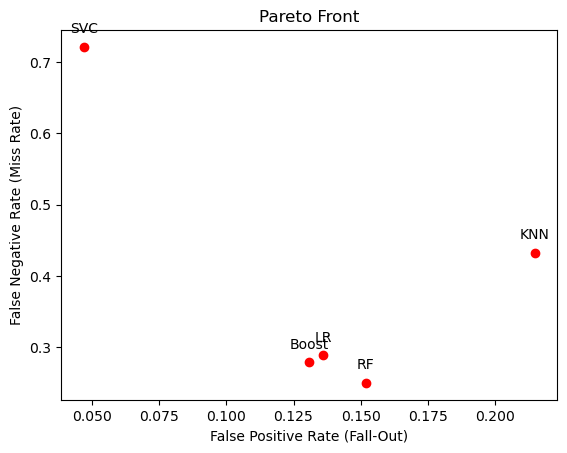

In [11]:
# Plot output
plt.scatter(FPR_axis, FNR_axis, color='r')
for i, label in enumerate(name_labels):
    # xy=(x, y) is the point position
    # xytext=(offset_x, offset_y) nudges the text so it doesn't overlap the dot
    plt.annotate(
        label, 
        (FPR_axis[i], FNR_axis[i]), 
        textcoords="offset points", 
        xytext=(0, 10), 
        ha='center'
    )
plt.xlabel("False Positive Rate (Fall-Out)")
plt.ylabel("False Negative Rate (Miss Rate)")
plt.title("Pareto Front")
plt.show()

# Milestone 2: default hyperparameters, new data pipeline

In [12]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

In [13]:
# Clear Containers and Build Final x and y axes
x_axis1.append(FPR_axis)
y_axis1.append(FNR_axis)

FPR_axis = []
FNR_axis = []

In [14]:
# Andy - Boosted Tree
boost_clf = ensemble.GradientBoostingClassifier(random_state=100)
# Train the model
boost_clf.fit(X_train, y_train)

# Make predictions
y_pred = boost_clf.predict(X_test)

tn, fp, fn, tp = confusion_matrix(y_truth, y_pred).ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

output = ordered_pair(tn, fp, fn, tp)
FPR_axis.append(output[0])
FNR_axis.append(output[1])
print(f'FPR = {output[0]:.04f} FNR = {output[1]:.04f}')

True Negatives: 166
False Positives: 25
False Negatives: 31
True Positives: 73
FPR = 0.1309 FNR = 0.2981


In [15]:
# Stevie - SVC
svc_clf = svm.SVC()

# Train the model
svc_clf.fit(X_train, y_train)

# Make predictions
y_pred = svc_clf.predict(X_test)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

output = ordered_pair(tn, fp, fn, tp)
FPR_axis.append(output[0])
FNR_axis.append(output[1])
print(f'FPR = {output[0]:.04f} FNR = {output[1]:.04f}')

True Negatives: 168
False Positives: 23
False Negatives: 26
True Positives: 78
FPR = 0.1204 FNR = 0.2500


In [16]:
# Asher - Logistic Classification
LC = LogisticRegression()

# Train the model
LC.fit(X_train, y_train)

# Make predictions
y_pred = LC.predict(X_test)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

output = ordered_pair(tn, fp, fn, tp)
FPR_axis.append(output[0])
FNR_axis.append(output[1])
print(f'FPR = {output[0]:.04f} FNR = {output[1]:.04f}')

True Negatives: 164
False Positives: 27
False Negatives: 30
True Positives: 74
FPR = 0.1414 FNR = 0.2885


In [17]:
# Shrey - KNN
KNNC = neighbors.KNeighborsClassifier()


KNNC.fit(X_train, y_train)
y_pred = KNNC.predict(X_test)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

output = ordered_pair(tn, fp, fn, tp)
FPR_axis.append(output[0])
FNR_axis.append(output[1])
print(f'FPR = {output[0]:.04f} FNR = {output[1]:.04f}')

True Negatives: 166
False Positives: 25
False Negatives: 30
True Positives: 74
FPR = 0.1309 FNR = 0.2885


In [18]:
# Val - Random Forest
RFC = ensemble.RandomForestClassifier()

# Train the model
RFC.fit(X_train, y_train)

# Make predictions
y_pred = RFC.predict(X_test)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

output = ordered_pair(tn, fp, fn, tp)
FPR_axis.append(output[0])
FNR_axis.append(output[1])
print(f'FPR = {output[0]:.04f} FNR = {output[1]:.04f}')

True Negatives: 159
False Positives: 32
False Negatives: 32
True Positives: 72
FPR = 0.1675 FNR = 0.3077


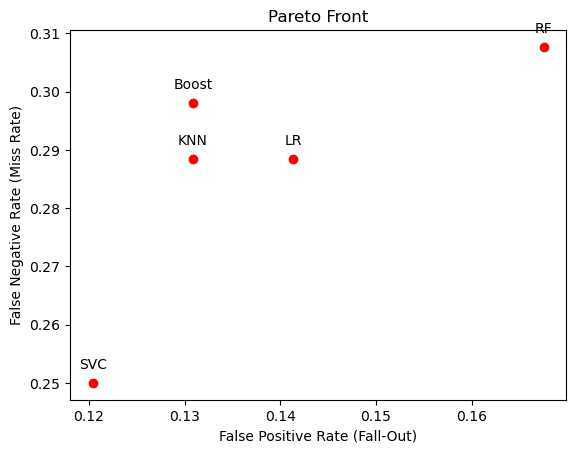

In [19]:
# Plot output
plt.scatter(FPR_axis, FNR_axis, color='r')
for i, label in enumerate(name_labels):
    # xy=(x, y) is the point position
    # xytext=(offset_x, offset_y) nudges the text so it doesn't overlap the dot
    plt.annotate(
        label, 
        (FPR_axis[i], FNR_axis[i]), 
        textcoords="offset points", 
        xytext=(0, 10), 
        ha='center'
    )
plt.xlabel("False Positive Rate (Fall-Out)")
plt.ylabel("False Negative Rate (Miss Rate)")
plt.title("Pareto Front")
plt.show()

# Milestone 3: Initial Grid Search, New Data Pipeline

In [20]:
x_axis1.append(FPR_axis)
y_axis1.append(FNR_axis)

FPR_axis = []
FNR_axis = []

In [21]:
# Andy - Boosted Tree

param_grid = {
    'learning_rate': [.01, .02, .04],
    'n_estimators': [50, 60, 70, 80, 90],
    'max_depth': [2,3,4],
    'subsample': [0.9, 1.0, 1.1]
}

boost_clf = ensemble.GradientBoostingClassifier(random_state=100)

grid_search = GridSearchCV(
    estimator=boost_clf,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)


optimal_boost_clf = grid_search.best_estimator_
print("Best C:", grid_search.best_params_)
print("Best CV accuracy:", grid_search.best_score_)
print("Held-out test accuracy:", optimal_boost_clf.score(X_test, y_test))


y_pred = optimal_boost_clf.predict(X_test)
y_truth = y_test

tn, fp, fn, tp = confusion_matrix(y_truth, y_pred).ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

output = ordered_pair(tn, fp, fn, tp)
FPR_axis.append(output[0])
FNR_axis.append(output[1])
print(f'FPR = {output[0]:.04f} FNR = {output[1]:.04f}')

Fitting 5 folds for each of 135 candidates, totalling 675 fits
Best C: {'learning_rate': 0.04, 'max_depth': 3, 'n_estimators': 80, 'subsample': 1.0}
Best CV accuracy: 0.8655241734092497
Held-out test accuracy: 0.823728813559322
True Negatives: 169
False Positives: 22
False Negatives: 30
True Positives: 74
FPR = 0.1152 FNR = 0.2885


C:\Users\thund\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
225 fits failed out of a total of 675.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
225 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\thund\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\thund\anaconda3\Lib\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "C:\Users\thund\anaconda3\Lib\site-packages\sklearn\base.py", line 436, in _validate_params
 

In [22]:
# Stevie - SVC

C_vals = [0.01, 0.1, 1, 10, 100]
cw_vals = [None, 'balanced']
gamma_vals = ['scale', 'auto', 0.01, 0.1, 1]
degree_vals = [2, 3, 4]

param_grid = [
    # RBF — the default, usually the best starting point
    {'kernel': ['rbf'],    'C': C_vals, 'class_weight': cw_vals, 'gamma': gamma_vals},
    # Linear — no gamma, no degree
    {'kernel': ['linear'], 'C': C_vals, 'class_weight': cw_vals},
    # Polynomial — has degree AND gamma
    {'kernel': ['poly'],   'C': C_vals, 'class_weight': cw_vals, 'gamma': gamma_vals, 'degree': degree_vals},
    # Sigmoid — has gamma
    {'kernel': ['sigmoid'],'C': C_vals, 'class_weight': cw_vals, 'gamma': gamma_vals},
]

svc_grid = GridSearchCV(
    svm.SVC(probability=False), 
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
)

svc_grid.fit(X_train, y_train)

best_svc = svc_grid.best_estimator_
print("Best C:", svc_grid.best_params_)
print("Best CV accuracy:", svc_grid.best_score_)
print("Held-out test accuracy:", best_svc.score(X_test, y_test))

y_pred = best_svc.predict(X_test)
y_truth = y_test

tn, fp, fn, tp = confusion_matrix(y_truth, y_pred).ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

output = ordered_pair(tn, fp, fn, tp)
FPR_axis.append(output[0])
FNR_axis.append(output[1])
print(f'FPR = {output[0]:.04f} FNR = {output[1]:.04f}')

Best C: {'C': 1, 'class_weight': 'balanced', 'gamma': 0.01, 'kernel': 'rbf'}
Best CV accuracy: 0.8497221112331991
Held-out test accuracy: 0.7966101694915254
True Negatives: 164
False Positives: 27
False Negatives: 33
True Positives: 71
FPR = 0.1414 FNR = 0.3173


In [23]:
# Asher - Logistic Classification
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"],  # liblinear supports both l1 and l2
    "class_weight": [None, "balanced"],
}
grid = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=5, scoring="accuracy")
grid.fit(X_train, y_train)


log_reg = grid.best_estimator_


y_pred = log_reg.predict(X_test)
y_truth = y_test

print("Best C:", grid.best_params_)
print("Best CV accuracy:", grid.best_score_)
print("Held-out test accuracy:", log_reg.score(X_test, y_test))

tn, fp, fn, tp = confusion_matrix(y_truth, y_pred).ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

output = ordered_pair(tn, fp, fn, tp)
FPR_axis.append(output[0])
FNR_axis.append(output[1])
print(f'FPR = {output[0]:.04f} FNR = {output[1]:.04f}')

Best C: {'C': 1, 'class_weight': None, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV accuracy: 0.7968907563025212
Held-out test accuracy: 0.8067796610169492
True Negatives: 164
False Positives: 27
False Negatives: 30
True Positives: 74
FPR = 0.1414 FNR = 0.2885


In [24]:
# Shrey - KNN
param_grid = {
    'n_neighbors': [7, 9, 11, 13, 15, 17, 19, 21, 23, 25],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

knn_grid = GridSearchCV(
    neighbors.KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='roc_auc'
)

knn_grid.fit(X_train, y_train)   # already scaled, already DataFrame

best_knn = knn_grid.best_estimator_

print("Best C:", knn_grid.best_params_)
print("Best CV accuracy:", knn_grid.best_score_)
print("Held-out test accuracy:", knn_grid.score(X_test, y_test))

y_pred = best_knn.predict(X_test)
y_truth = y_test

tn, fp, fn, tp = confusion_matrix(y_truth, y_pred).ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

output = ordered_pair(tn, fp, fn, tp)
FPR_axis.append(output[0])
FNR_axis.append(output[1])
print(f'FPR = {output[0]:.04f} FNR = {output[1]:.04f}')


Best C: {'n_neighbors': 19, 'p': 1, 'weights': 'distance'}
Best CV accuracy: 0.849945676075761
Held-out test accuracy: 0.8165525573902537
True Negatives: 160
False Positives: 31
False Negatives: 29
True Positives: 75
FPR = 0.1623 FNR = 0.2788


In [25]:
# Val - Random Forest


param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': [None, 'balanced'],
}

RF_grid = GridSearchCV(
    ensemble.RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
)

RF_grid.fit(X_train, y_train)

best_rf = RF_grid.best_estimator_


print("Best C:", RF_grid.best_params_)
print("Best CV accuracy:", RF_grid.best_score_)
print("Held-out test accuracy:", RF_grid.score(X_test, y_test))

y_pred = best_rf.predict(X_test)
y_truth = y_test

tn, fp, fn, tp = confusion_matrix(y_truth, y_pred).ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

output = ordered_pair(tn, fp, fn, tp)
FPR_axis.append(output[0])
FNR_axis.append(output[1])
print(f'FPR = {output[0]:.04f} FNR = {output[1]:.04f}')


Best C: {'class_weight': None, 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 200}
Best CV accuracy: 0.8237815126050421
Held-out test accuracy: 0.8203389830508474
True Negatives: 166
False Positives: 25
False Negatives: 28
True Positives: 76
FPR = 0.1309 FNR = 0.2692


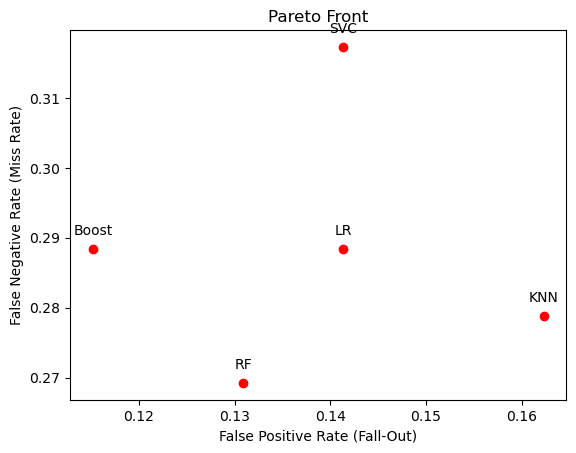

In [26]:
# Plot output
plt.scatter(FPR_axis, FNR_axis, color='r')

for i, label in enumerate(name_labels):
    # xy=(x, y) is the point position
    # xytext=(offset_x, offset_y) nudges the text so it doesn't overlap the dot
    plt.annotate(
        label, 
        (FPR_axis[i], FNR_axis[i]), 
        textcoords="offset points", 
        xytext=(0, 10), 
        ha='center'
    )

plt.xlabel("False Positive Rate (Fall-Out)")
plt.ylabel("False Negative Rate (Miss Rate)")
plt.title("Pareto Front")
plt.show()

# Milestone 4: Final Grid Search, New Data Pipeline

In [27]:
x_axis1.append(FPR_axis)
y_axis1.append(FNR_axis)

FPR_axis = []
FNR_axis = []

In [28]:
# Andy - Boosted Tree

param_grid = {
    'learning_rate': [.03, .04, .05],
    'n_estimators': [76, 78, 80, 84, 84],
    'max_depth': [2,3,4],
    'subsample': [0.9, 1.0, 1.1]
}

boost_clf = ensemble.GradientBoostingClassifier(random_state=100)

grid_search = GridSearchCV(
    estimator=boost_clf,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)


optimal_boost_clf = grid_search.best_estimator_
print("Best C:", grid_search.best_params_)
print("Best CV accuracy:", grid_search.best_score_)
print("Held-out test accuracy:", optimal_boost_clf.score(X_test, y_test))


y_pred = optimal_boost_clf.predict(X_test)
y_truth = y_test

tn, fp, fn, tp = confusion_matrix(y_truth, y_pred).ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

output = ordered_pair(tn, fp, fn, tp)
FPR_axis.append(output[0])
FNR_axis.append(output[1])
print(f'FPR = {output[0]:.04f} FNR = {output[1]:.04f}')

Fitting 5 folds for each of 135 candidates, totalling 675 fits
Best C: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 84, 'subsample': 1.0}
Best CV accuracy: 0.8655769799054372
Held-out test accuracy: 0.823728813559322
True Negatives: 168
False Positives: 23
False Negatives: 29
True Positives: 75
FPR = 0.1204 FNR = 0.2788


C:\Users\thund\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
225 fits failed out of a total of 675.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
225 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\thund\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\thund\anaconda3\Lib\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "C:\Users\thund\anaconda3\Lib\site-packages\sklearn\base.py", line 436, in _validate_params
 

In [29]:
# Stevie - SVC

C_vals = [0.5, 1, 1.5, 2]
cw_vals = ['balanced']
gamma_vals = [.005, 0.01, .02, .03]
degree_vals = [2, 3, 4]

param_grid = [
    # RBF — the default, usually the best starting point
    {'kernel': ['rbf'],    'C': C_vals, 'class_weight': cw_vals, 'gamma': gamma_vals},
]

svc_grid = GridSearchCV(
    svm.SVC(probability=False),   
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
)

svc_grid.fit(X_train, y_train)

best_svc = svc_grid.best_estimator_
print("Best C:", svc_grid.best_params_)
print("Best CV accuracy:", svc_grid.best_score_)
print("Held-out test accuracy:", best_svc.score(X_test, y_test))

y_pred = best_svc.predict(X_test)
y_truth = y_test

tn, fp, fn, tp = confusion_matrix(y_truth, y_pred).ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

output = ordered_pair(tn, fp, fn, tp)
FPR_axis.append(output[0])
FNR_axis.append(output[1])
print(f'FPR = {output[0]:.04f} FNR = {output[1]:.04f}')

Best C: {'C': 2, 'class_weight': 'balanced', 'gamma': 0.01, 'kernel': 'rbf'}
Best CV accuracy: 0.8505424761928545
Held-out test accuracy: 0.7966101694915254
True Negatives: 164
False Positives: 27
False Negatives: 33
True Positives: 71
FPR = 0.1414 FNR = 0.3173


In [30]:
# Asher - Logistic Classification
param_grid = {
    "C": [.5, .6, .7, .8, .9, 1],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"],  # liblinear supports both l1 and l2
    "class_weight": [None],
}
grid = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=5, scoring="accuracy")
grid.fit(X_train, y_train)


log_reg = grid.best_estimator_


y_pred = log_reg.predict(X_test)
y_truth = y_test

print("Best C:", grid.best_params_)
print("Best CV accuracy:", grid.best_score_)
print("Held-out test accuracy:", log_reg.score(X_test, y_test))

tn, fp, fn, tp = confusion_matrix(y_truth, y_pred).ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

output = ordered_pair(tn, fp, fn, tp)
FPR_axis.append(output[0])
FNR_axis.append(output[1])
print(f'FPR = {output[0]:.04f} FNR = {output[1]:.04f}')

Best C: {'C': 0.8, 'class_weight': None, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV accuracy: 0.7968907563025212
Held-out test accuracy: 0.8067796610169492
True Negatives: 164
False Positives: 27
False Negatives: 30
True Positives: 74
FPR = 0.1414 FNR = 0.2885


In [31]:
# Shrey - KNN
param_grid = {
    'n_neighbors': [19, 19, 20],
    'weights': ['distance'],
    'p': [1]
}

knn_grid = GridSearchCV(
    neighbors.KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='roc_auc'
)

knn_grid.fit(X_train, y_train)   # already scaled, already DataFrame

best_knn = knn_grid.best_estimator_

print("Best C:", knn_grid.best_params_)
print("Best CV accuracy:", knn_grid.best_score_)
print("Held-out test accuracy:", knn_grid.score(X_test, y_test))

y_pred = best_knn.predict(X_test)
y_truth = y_test

tn, fp, fn, tp = confusion_matrix(y_truth, y_pred).ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

output = ordered_pair(tn, fp, fn, tp)
FPR_axis.append(output[0])
FNR_axis.append(output[1])
print(f'FPR = {output[0]:.04f} FNR = {output[1]:.04f}')


Best C: {'n_neighbors': 19, 'p': 1, 'weights': 'distance'}
Best CV accuracy: 0.849945676075761
Held-out test accuracy: 0.8165525573902537
True Negatives: 160
False Positives: 31
False Negatives: 29
True Positives: 75
FPR = 0.1623 FNR = 0.2788


In [32]:
# Val - Random Forest


param_grid = {
    'n_estimators': [150, 175, 200, 225, 250],
    'max_depth': [8, 9, 10, 11, 12],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [2, 3],
    'class_weight': [None],
}

RF_grid = GridSearchCV(
    ensemble.RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
)

RF_grid.fit(X_train, y_train)

best_rf = RF_grid.best_estimator_


print("Best C:", RF_grid.best_params_)
print("Best CV accuracy:", RF_grid.best_score_)
print("Held-out test accuracy:", RF_grid.score(X_test, y_test))

y_pred = best_rf.predict(X_test)
y_truth = y_test

tn, fp, fn, tp = confusion_matrix(y_truth, y_pred).ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

output = ordered_pair(tn, fp, fn, tp)
FPR_axis.append(output[0])
FNR_axis.append(output[1])
print(f'FPR = {output[0]:.04f} FNR = {output[1]:.04f}')


Best C: {'class_weight': None, 'max_depth': 11, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 175}
Best CV accuracy: 0.8254481792717087
Held-out test accuracy: 0.823728813559322
True Negatives: 167
False Positives: 24
False Negatives: 28
True Positives: 76
FPR = 0.1257 FNR = 0.2692


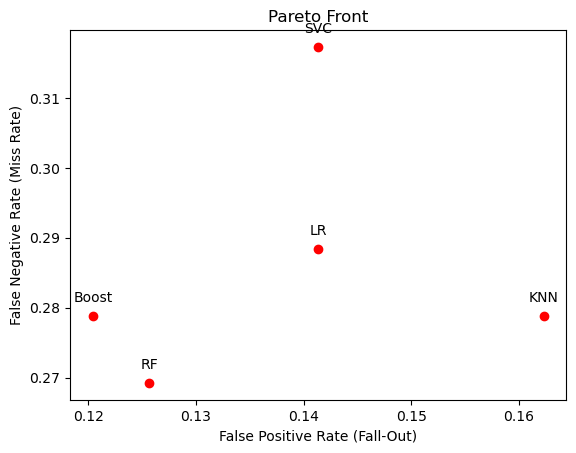

In [33]:
# Plot output
plt.scatter(FPR_axis, FNR_axis, color='r')

for i, label in enumerate(name_labels):
    # xy=(x, y) is the point position
    # xytext=(offset_x, offset_y) nudges the text so it doesn't overlap the dot
    plt.annotate(
        label, 
        (FPR_axis[i], FNR_axis[i]), 
        textcoords="offset points", 
        xytext=(0, 10), 
        ha='center'
    )

plt.xlabel("False Positive Rate (Fall-Out)")
plt.ylabel("False Negative Rate (Miss Rate)")
plt.title("Pareto Front")
plt.show()

# Final Pareto Frontier

In [38]:
points = np.column_stack([FPR_axis, FNR_axis])   # shape (n, 2)

def pareto_layer(pts):
    """Return indices (into pts) of the non-dominated points."""
    order = np.lexsort((pts[:, 1], pts[:, 0]))   # sort by FPR, then FNR
    sorted_pts = pts[order]
    keep = []
    best_fnr = np.inf
    for idx, (_, y) in zip(order, sorted_pts):
        if y < best_fnr:
            keep.append(idx)
            best_fnr = y
    return np.array(keep)

# --- Layer 1 (primary front) ---
layer1_idx = pareto_layer(points)
layer1 = points[layer1_idx]

# --- Layer 2 (secondary front) ---
remaining_mask = np.ones(len(points), dtype=bool)
remaining_mask[layer1_idx] = False
layer2_idx = pareto_layer(points[remaining_mask])
# map back to original indices
original_remaining = np.where(remaining_mask)[0]
layer2_idx = original_remaining[layer2_idx]
layer2 = points[layer2_idx]

layer1_full = np.vstack([[0, 1], layer1, [1, 0]])
layer2_full = np.vstack([[0, 1], layer2, [1, 0]])

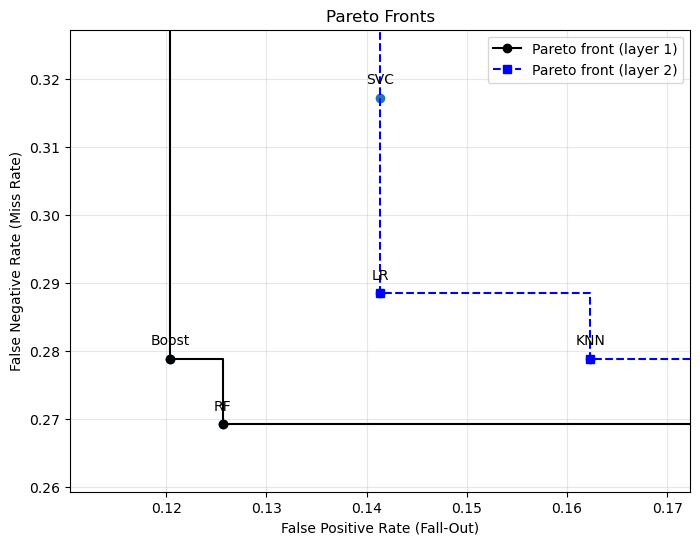

In [40]:
plt.figure(figsize=(8, 6))

plt.scatter(points[:, 0], points[:, 1])

for i, label in enumerate(name_labels):
    plt.annotate(label,
                 (points[i, 0], points[i, 1]),
                 textcoords="offset points",
                 xytext=(0, 10),
                 ha='center')

plt.plot(layer1_full[:, 0], layer1_full[:, 1],
         color='k', linestyle='-', marker='o',
         drawstyle='steps-post', label='Pareto front (layer 1)')

if len(layer2) > 1:
    layer2_full = np.vstack([[0, 1], layer2, [1, 0]])
    plt.plot(layer2_full[:, 0], layer2_full[:, 1],
             color='b', linestyle='--', marker='s',
             drawstyle='steps-post', label='Pareto front (layer 2)')

# Tight window around the actual points — the spanned corners get clipped
pad = 0.01
plt.xlim(points[:, 0].min() - pad, points[:, 0].max() + pad)
plt.ylim(points[:, 1].min() - pad, points[:, 1].max() + pad)

plt.xlabel("False Positive Rate (Fall-Out)")
plt.ylabel("False Negative Rate (Miss Rate)")
plt.title("Pareto Fronts")
plt.legend()
plt.grid(alpha=0.3)
plt.show()